# NN - Домашнее задание 1

**Kaggle nickname:** Zakharov Roman  
**ФИО:** Захаров Роман  
**Итоговая позиция на private leaderboard:** 25  
**Private score:** 0.768978  

## Intro

В соревновании решалась задача регрессии: по описанию вакансии нужно предсказать `log_salary_from`, то есть логарифм нижней границы зарплатного диапазона. Метрика качества - коэффициент детерминации `R2`.

Основное решение состоит из двух моделей, которые используют один и тот же исходный текст по-разному:

1. Самописная нейросеть на PyTorch. Текстовые признаки переводятся в TF-IDF, затем сжимаются через `TruncatedSVD`, после чего подаются в MLP-регрессию.
2. Ridge-регрессия на полной sparse TF-IDF матрице без SVD-сжатия.

Финальный сабмит получен усреднением предсказаний этих двух моделей в пропорции `50% / 50%`.

Скриншот итоговой позиции на leaderboard:
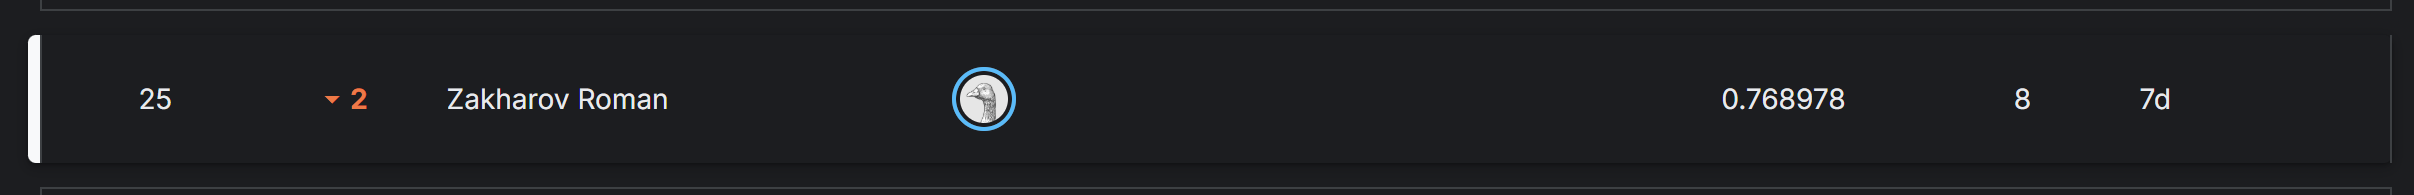

In [ ]:
import os
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from scipy.sparse import csr_matrix, hstack

warnings.filterwarnings("ignore")

RUN_STARTED_AT = time.time()

def log_step(message: str) -> None:
    elapsed = time.time() - RUN_STARTED_AT
    print(f"[{time.strftime('%H:%M:%S')}] +{elapsed:7.1f}s | {message}", flush=True)


SEED = 42
DATA_DIR = Path(".")
TARGET = "log_salary_from"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)
log_step(f"Device: {DEVICE}")


In [ ]:
def find_sample_submission(data_dir: Path) -> Path:
    candidates = [
        data_dir / "sample_submission.csv",
        data_dir / "sample_submition.csv",  # file in this competition folder has this spelling
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("sample_submission.csv / sample_submition.csv not found")

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
sample_path = find_sample_submission(DATA_DIR)

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print("train:", train.shape)
print("test:", test.shape)
print("sample submission:", sample_submission.shape)
display(train.head(3))
display(test.head(3))
display(sample_submission.head(3))

train: (16667, 8)
test: (5556, 6)
sample submission: (5556, 2)


In [ ]:
print("Train missing values:")
display(train.isna().sum())

print("Test missing values:")
display(test.isna().sum())

print("Target distribution:")
display(train[TARGET].describe())

plt.figure(figsize=(7, 4))
plt.hist(train[TARGET], bins=40)
plt.title("Distribution of log_salary_from")
plt.xlabel("log_salary_from")
plt.ylabel("count")
plt.show()


Train missing values:
title                 0
location              0
company               0
skills             5825
description           0
experience_from       0
salary_from           0
log_salary_from       0
dtype: int64

Test missing values:
title                 0
location              0
company               0
skills             2014
description           0
experience_from       0
dtype: int64

Target distribution:
count    16667.000000
mean         4.516523
std          0.629785
min          1.629241
25%          4.094345
50%          4.499810
75%          5.010635
max          6.907755
Name: log_salary_from, dtype: float64


## Подготовка признаков

В данных есть несколько текстовых полей: `title`, `location`, `company`, `skills`, `description`. Зарплата в этой задаче сильно зависит от должности, навыков, города и технологического стека, поэтому основной источник информации - текст.

Поле `salary_from` не используется как признак: в train оно напрямую связано с целевой переменной, а в test такого столбца нет. Использование этого поля привело бы к утечке.

Текст собирается в одну строку. `title` и `skills` повторяются три раза, потому что название вакансии и навыки обычно несут более сильный сигнал о зарплате, чем длинное описание.

Используются два вида TF-IDF:

- word TF-IDF по словам и парам слов;
- char TF-IDF по символьным n-граммам.

Word TF-IDF хорошо ловит фразы вроде `data scientist`, `product owner`, `системный администратор`. Char TF-IDF полезен для технологий, сокращений и разных написаний: `python`, `postgres`, `sql`, `1c`, `devops`.

Для нейросети sparse TF-IDF дополнительно сжимается через `TruncatedSVD`. Для Ridge-регрессии используется полная sparse TF-IDF матрица без сжатия.

In [ ]:
TEXT_COLS = ["title", "location", "company", "skills", "description"]
NUMERIC_COLS = ["experience_from"]

def prepare_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in TEXT_COLS:
        out[col] = out[col].fillna("").astype(str)
    out["experience_from"] = pd.to_numeric(out["experience_from"], errors="coerce").fillna(0.0)
    return out

def make_text(df: pd.DataFrame) -> pd.Series:
    df = prepare_frame(df)
    return (
        (df["title"] + " ") * 3
        + (df["skills"] + " ") * 3
        + df["location"] + " "
        + df["company"] + " "
        + df["description"]
    ).str.lower()

def make_numeric_features(df: pd.DataFrame) -> np.ndarray:
    df = prepare_frame(df)
    feats = pd.DataFrame(index=df.index)
    feats["experience_from"] = df["experience_from"].clip(0, 20)
    feats["experience_from_sq"] = feats["experience_from"] ** 2
    feats["has_skills"] = (df["skills"].str.len() > 0).astype(float)

    for col in TEXT_COLS:
        text = df[col].fillna("").astype(str)
        feats[f"{col}_len_log"] = np.log1p(text.str.len())
        feats[f"{col}_words_log"] = np.log1p(text.str.split().str.len())

    full_text = make_text(df)
    feats["text_len_log"] = np.log1p(full_text.str.len())
    feats["text_words_log"] = np.log1p(full_text.str.split().str.len())
    return feats.astype(np.float32).values

class FeatureBuilder:
    def __init__(
        self,
        word_features: int = 30000,
        char_features: int = 15000,
        svd_components: int = 384,
        random_state: int = 42,
    ):
        self.vectorizer = FeatureUnion(
            [
                (
                    "word",
                    TfidfVectorizer(
                        ngram_range=(1, 2),
                        min_df=2,
                        max_features=word_features,
                        sublinear_tf=True,
                        dtype=np.float32,
                    ),
                ),
                (
                    "char",
                    TfidfVectorizer(
                        analyzer="char_wb",
                        ngram_range=(3, 5),
                        min_df=2,
                        max_features=char_features,
                        sublinear_tf=True,
                        dtype=np.float32,
                    ),
                ),
            ]
        )
        self.svd = TruncatedSVD(n_components=svd_components, random_state=random_state)
        self.scaler = StandardScaler()

    def fit(self, df: pd.DataFrame, extra_unlabeled_df: pd.DataFrame | None = None):
        fit_df = df if extra_unlabeled_df is None else pd.concat([df, extra_unlabeled_df], axis=0, ignore_index=True)
        fit_text = make_text(fit_df)
        fit_num = make_numeric_features(fit_df)

        log_step(f"TF-IDF fit on {len(fit_df)} rows")
        sparse_text = self.vectorizer.fit_transform(fit_text)
        log_step(f"SVD fit: sparse shape={sparse_text.shape}")
        self.svd.fit(sparse_text)
        self.scaler.fit(fit_num)
        log_step("FeatureBuilder fitted")
        return self

    def transform(self, df: pd.DataFrame) -> np.ndarray:
        sparse_text = self.vectorizer.transform(make_text(df))
        text_features = self.svd.transform(sparse_text).astype(np.float32)
        num_features = self.scaler.transform(make_numeric_features(df)).astype(np.float32)
        return np.hstack([text_features, num_features]).astype(np.float32)


def build_sparse_ridge_features(feature_builder: FeatureBuilder, df: pd.DataFrame):
    sparse_text = feature_builder.vectorizer.transform(make_text(df))
    num = feature_builder.scaler.transform(make_numeric_features(df)).astype(np.float32)
    return hstack([sparse_text, csr_matrix(num)], format="csr")


In [ ]:
y = train[TARGET].astype(np.float32).values

target_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")
train_idx, valid_idx = train_test_split(
    np.arange(len(train)),
    test_size=0.2,
    random_state=SEED,
    stratify=target_bins,
)

train_part = train.iloc[train_idx].reset_index(drop=True)
valid_part = train.iloc[valid_idx].reset_index(drop=True)
y_train = y[train_idx]
y_valid = y[valid_idx]

log_step("Fitting TF-IDF/SVD features for validation split")
valid_features = FeatureBuilder(
    word_features=50000,
    char_features=30000,
    svd_components=384,
    random_state=SEED,
)
valid_features.fit(train_part)
X_train = valid_features.transform(train_part)
X_valid = valid_features.transform(valid_part)

log_step(f"X_train: {X_train.shape}")
log_step(f"X_valid: {X_valid.shape}")
log_step(f"y_train mean/std: {float(y_train.mean()):.4f} / {float(y_train.std()):.4f}")


[00:00:00] | Fitting TF-IDF/SVD features for validation split
[00:00:00] | TF-IDF fit on 13333 rows
[00:00:00] | SVD fit: sparse shape=(13333, 80000)
[00:00:00] | FeatureBuilder fitted
[00:00:00] | X_train: (13333, 399)
[00:00:00] | X_valid: (3334, 399)
[00:00:00] | y_train mean/std: 4.5167 / 0.6287


## Самописная нейросеть на PyTorch

Нейросетевая часть нужна для выполнения основного требования задания: реализовать и обучить собственную архитектуру на PyTorch.

MLP получает плотные признаки: компоненты `TruncatedSVD` и несколько числовых признаков. Перед обучением целевая переменная стандартизуется, чтобы модель предсказывала значения в более удобном масштабе.

Архитектура:

- `BatchNorm1d` стабилизирует масштаб входов;
- несколько `Linear`-слоёв учат нелинейные комбинации признаков;
- `SiLU` используется как функция активации;
- `Dropout` и `weight_decay` снижают переобучение;
- `SmoothL1Loss` устойчивее к выбросам, чем обычный MSE.

In [ ]:
class SalaryDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray | None = None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

class SalaryMLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 512),
            nn.SiLU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Dropout(0.10),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x)

def predict_nn(model: nn.Module, X: np.ndarray, y_mean: float, y_std: float, batch_size: int = 512) -> np.ndarray:
    model.eval()
    loader = DataLoader(SalaryDataset(X), batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            pred = model(xb).detach().cpu().numpy().reshape(-1)
            preds.append(pred)
    preds = np.concatenate(preds)
    return preds * y_std + y_mean

def train_nn(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_val: np.ndarray | None = None,
    y_val: np.ndarray | None = None,
    seed: int = 42,
    max_epochs: int = 60,
    batch_size: int = 256,
    lr: float = 1e-3,
    weight_decay: float = 2e-4,
    patience: int = 10,
):
    seed_everything(seed)
    y_mean = float(y_tr.mean())
    y_std = float(y_tr.std() + 1e-8)
    y_tr_scaled = (y_tr - y_mean) / y_std

    model = SalaryMLP(X_tr.shape[1]).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    criterion = nn.SmoothL1Loss(beta=0.5)

    train_loader = DataLoader(
        SalaryDataset(X_tr, y_tr_scaled),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
        num_workers=0,
    )

    best_state = None
    best_r2 = -np.inf
    best_epoch = 0
    no_improve = 0
    history = []

    log_step(f"Start NN training: rows={len(X_tr)}, input_dim={X_tr.shape[1]}, max_epochs={max_epochs}")
    for epoch in range(1, max_epochs + 1):
        epoch_started = time.time()
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
            optimizer.step()
            train_losses.append(float(loss.detach().cpu()))
        scheduler.step()

        row = {"epoch": epoch, "train_loss": float(np.mean(train_losses))}
        if X_val is not None and y_val is not None:
            val_pred = predict_nn(model, X_val, y_mean, y_std)
            val_r2 = r2_score(y_val, val_pred)
            val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
            row.update({"val_r2": float(val_r2), "val_rmse": float(val_rmse)})

            if val_r2 > best_r2:
                best_r2 = val_r2
                best_epoch = epoch
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1

            print(
                f"Epoch {epoch:03d} | loss={row['train_loss']:.4f} "
                f"| val_R2={val_r2:.5f} | val_RMSE={val_rmse:.5f} "
                f"| epoch_time={time.time() - epoch_started:.1f}s",
                flush=True,
            )
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}; best epoch = {best_epoch}, best R2 = {best_r2:.5f}", flush=True)
                break
        else:
            print(f"Epoch {epoch:03d} | loss={row['train_loss']:.4f} | epoch_time={time.time() - epoch_started:.1f}s", flush=True)

        history.append(row)

    if best_state is not None:
        model.load_state_dict(best_state)
    elif history:
        best_epoch = history[-1]["epoch"]

    return model, y_mean, y_std, pd.DataFrame(history), best_epoch


In [ ]:
model, y_mean, y_std, history, best_epoch = train_nn(
    X_train,
    y_train,
    X_valid,
    y_valid,
    seed=SEED,
    max_epochs=70,
    batch_size=512,
    lr=1e-3,
    weight_decay=2e-4,
    patience=10,
)

valid_pred = predict_nn(model, X_valid, y_mean, y_std)
valid_r2 = r2_score(y_valid, valid_pred)
valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
log_step(f"Validation R2: {valid_r2:.6f}")
log_step(f"Validation RMSE: {valid_rmse:.6f}")
log_step(f"Best epoch: {best_epoch}")

log_step("Training Ridge validation baseline")
X_train_ridge = build_sparse_ridge_features(valid_features, train_part)
X_valid_ridge = build_sparse_ridge_features(valid_features, valid_part)

ridge_results = []
best_ridge_r2 = -np.inf
best_ridge_pred = None
RIDGE_ALPHA = None

for alpha in [0.3, 1.0, 3.0, 10.0, 30.0, 100.0]:
    ridge = Ridge(alpha=alpha, solver="lsqr")
    ridge.fit(X_train_ridge, y_train)
    ridge_pred = ridge.predict(X_valid_ridge).astype(np.float32)
    ridge_r2 = r2_score(y_valid, ridge_pred)
    ridge_rmse = np.sqrt(mean_squared_error(y_valid, ridge_pred))
    ridge_results.append({"alpha": alpha, "ridge_r2": ridge_r2, "ridge_rmse": ridge_rmse})
    log_step(f"Ridge alpha={alpha}: R2={ridge_r2:.6f}; RMSE={ridge_rmse:.6f}")
    if ridge_r2 > best_ridge_r2:
        best_ridge_r2 = ridge_r2
        best_ridge_pred = ridge_pred
        RIDGE_ALPHA = alpha

best_blend_r2 = -np.inf
BLEND_NN_WEIGHT = 1.0
for w_nn in np.linspace(0.0, 1.0, 21):
    blend_pred = w_nn * valid_pred + (1.0 - w_nn) * best_ridge_pred
    blend_r2 = r2_score(y_valid, blend_pred)
    if blend_r2 > best_blend_r2:
        best_blend_r2 = blend_r2
        BLEND_NN_WEIGHT = float(w_nn)

log_step(f"Best Ridge alpha: {RIDGE_ALPHA}; Ridge R2: {best_ridge_r2:.6f}")
log_step(f"Best blend validation R2: {best_blend_r2:.6f}; NN weight: {BLEND_NN_WEIGHT:.2f}; Ridge weight: {1.0 - BLEND_NN_WEIGHT:.2f}")
display(pd.DataFrame(ridge_results).sort_values("ridge_r2", ascending=False))


Epoch 001 | loss=0.3525 | val_R2=0.47080 | val_RMSE=0.46119
Epoch 002 | loss=0.2447 | val_R2=0.68069 | val_RMSE=0.35824
Epoch 003 | loss=0.2175 | val_R2=0.69678 | val_RMSE=0.34910
...
Early stopping at epoch 17; best epoch = 7, best R2 = 0.70596
[00:00:00] | Validation R2: 0.705960
[00:00:00] | Validation RMSE: 0.343778
[00:00:00] | Best epoch: 7
[00:00:00] | Ridge alpha=0.3: R2=0.711616; RMSE=0.340455
[00:00:00] | Ridge alpha=1.0: R2=0.726434; RMSE=0.331593
[00:00:00] | Ridge alpha=3.0: R2=0.725090; RMSE=0.332407
[00:00:00] | Ridge alpha=10.0: R2=0.701785; RMSE=0.346210
[00:00:00] | Ridge alpha=30.0: R2=0.659529; RMSE=0.369926
[00:00:00] | Ridge alpha=100.0: R2=0.596638; RMSE=0.402645
[00:00:00] | Best Ridge alpha: 1.0; Ridge R2: 0.726434


## Финальное обучение и формирование submission

Финальная стратегия была выбрана после нескольких отправок на Kaggle.

Результаты отдельных вариантов:

| Файл | Public score |
|---|---:|
| `submission_ridge.csv` | 0.750031 |
| `submission_blend_nn70_ridge30.csv` | 0.756735 |
| `submission_blend_nn60_ridge40.csv` | 0.760575 |
| `submission_blend_nn50_ridge50.csv` | 0.762816 |

Лучший public score дал blend `50% NN + 50% Ridge`. На private leaderboard итоговый score составил `0.768978`, позиция - 25.

In [ ]:
FINAL_SEEDS = [42, 2026, 777]
FINAL_EPOCHS = max(20, int(best_epoch) + 3)
FINAL_BATCH_SIZE = 512
FINAL_BLEND_NN_WEIGHT = 0.50

log_step(f"Final seeds: {FINAL_SEEDS}")
log_step(f"Final epochs per model: {FINAL_EPOCHS}")
log_step(f"Device for MLP: {DEVICE}")

log_step("Fitting final TF-IDF/SVD on train + test texts")
final_features = FeatureBuilder(
    word_features=50000,
    char_features=30000,
    svd_components=384,
    random_state=SEED,
)
final_features.fit(train, extra_unlabeled_df=test)

log_step("Transforming full train and test")
X_full = final_features.transform(train)
X_test = final_features.transform(test)
y_full = train[TARGET].astype(np.float32).values

test_predictions = []
for seed in FINAL_SEEDS:
    log_step(f"Training final MLP with seed={seed}")
    final_model, final_y_mean, final_y_std, _, _ = train_nn(
        X_full,
        y_full,
        X_val=None,
        y_val=None,
        seed=seed,
        max_epochs=FINAL_EPOCHS,
        batch_size=FINAL_BATCH_SIZE,
        lr=1e-3,
        weight_decay=2e-4,
        patience=FINAL_EPOCHS + 1,
    )
    test_predictions.append(predict_nn(final_model, X_test, final_y_mean, final_y_std))

nn_test_pred = np.mean(test_predictions, axis=0)

log_step("Training final Ridge")
X_full_ridge = build_sparse_ridge_features(final_features, train)
X_test_ridge = build_sparse_ridge_features(final_features, test)
final_ridge = Ridge(alpha=RIDGE_ALPHA, solver="lsqr")
final_ridge.fit(X_full_ridge, y_full)
ridge_test_pred = final_ridge.predict(X_test_ridge).astype(np.float32)

test_pred = FINAL_BLEND_NN_WEIGHT * nn_test_pred + (1.0 - FINAL_BLEND_NN_WEIGHT) * ridge_test_pred
test_pred = np.clip(test_pred, train[TARGET].min() - 0.1, train[TARGET].max() + 0.1)

submission = sample_submission.copy()
prediction_column = [c for c in submission.columns if c.lower() not in {"index", "id"}][0]
submission[prediction_column] = test_pred
submission.to_csv("submission.csv", index=False)

log_step("Saved submission.csv")
display(submission.head())
display(submission[prediction_column].describe())


[00:00:00] | Final seeds: [42, 2026, 777]
[00:00:00] | Final epochs per model: 20
[00:00:00] | Device for MLP: cuda
[00:00:00] | Training final Ridge
[00:00:00] | Saved submission.csv
   index  prediction
0      0    5.536675
1      1    3.882543
2      2    4.234574
3      3    4.514046
4      4    4.610110


## Анализ экспериментов

### Что проверялось

Базовая версия состояла из TF-IDF/SVD признаков и MLP на PyTorch. Такой подход дал сильный стартовый результат, потому что SVD собирает общий смысл вакансии в компактные плотные признаки, а нейросеть учит нелинейные зависимости между опытом, текстом и зарплатой.

Затем проверялась предобученная модель `cointegrated/rubert-tiny2`. Fine-tuning оказался слабее TF-IDF-подхода. Вероятная причина - зарплата сильно зависит от коротких точных маркеров (`senior`, `lead`, `1C`, `SQL`, `Москва`, `DevOps`), а TF-IDF и Ridge используют такие маркеры напрямую. Маленькая transformer-модель на ограниченной длине текста не дала преимущества.

Наиболее полезным дополнением стала Ridge-регрессия на полной sparse TF-IDF матрице. В отличие от MLP, Ridge не получает сжатые SVD-признаки, а видит конкретные слова, пары слов и символьные фрагменты. Поэтому Ridge лучше ловит точные зарплатные маркеры, а MLP дополняет его более сглаженным представлением вакансии.

### Причины итогового результата

Лучший результат дал blend `50% NN + 50% Ridge`. Это означает, что обе модели содержали полезную и различающуюся информацию. Ridge лучше работает с точными текстовыми совпадениями, MLP лучше обобщает сжатые SVD-признаки. Усреднение снижает ошибку, если модели ошибаются в разных местах.

### Применимость в бизнес-процессах

Такое решение можно использовать как модуль предварительной оценки зарплатной вилки при публикации вакансии или аналитике рынка труда. По тексту вакансии система может оценить ожидаемый уровень зарплаты и подсветить объявления, где указанная зарплата выглядит нетипично низкой или высокой для похожих ролей. Также модель можно применять для мониторинга рынка: сравнивать зарплатные ожидания по городам, технологиям, seniority и типам вакансий.

### Ограничения

Модель ориентируется на текстовые закономерности в исторических данных. Если рынок резко меняется или в данных есть систематические смещения, предсказания будут наследовать эти смещения. Кроме того, модель предсказывает `log_salary_from`, а не полную вилку и не фактическую компенсацию с бонусами.

## Outro

Итоговое решение сочетает требуемую самописную PyTorch-архитектуру и сильный классический текстовый baseline. Финальная позиция на private leaderboard - 25, private score - 0.768978. Основной вывод по соревнованию: для текстовой регрессии на вакансиях TF-IDF и регуляризованные линейные модели оказались очень сильными, а нейросеть дала дополнительный полезный сигнал при смешивании предсказаний.